In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
df = pd.read_csv("../data/raw/Mutual_Funds.csv")

df.head(5)

,Unnamed: 0,Scheme,Category,Type,Benchmark,Net_Asset_Value(Rs.),CAGR% 6 Months,CAGR% 1 Year,CAGR% 3 Year,Min. Invest(Rs.),Exp. Ratio(%),SIP Min. Inv.(Rs.)
0,0,Kotak Corporate Bond Fund(M-IDCW),Debt - Corporate Bond Fund,Open ended,CRISIL Corporate Bond Index,"1,035.21",5.05,3.69,5.29,"5,000.00",0.67,"1,000.00"
1,1,Kotak Corporate Bond Fund(G),Debt - Corporate Bond Fund,Open ended,CRISIL Corporate Bond Index,"3,133.58",5.05,3.69,5.32,"5,000.00",0.67,"1,000.00"
2,2,Aditya Birla SL Liquid Fund(DD-IDCW),Debt - Liquid Fund,Open ended,N/A,100.20,5.21,4.10,4.45,"1,000.00",0.34,NaN
3,3,Aditya Birla SL Liquid Fund(G),Debt - Liquid Fund,Open ended,N/A,356.66,5.21,4.17,5.28,"1,000.00",0.34,"1,000.00"
4,4,Aditya Birla SL Liquid Fund(W-IDCW),Debt - Liquid Fund,Open ended,N/A,100.34,5.10,4.08,4.43,"1,000.00",0.34,NaN


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2556
Columns: 12


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556 entries, 0 to 2555
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            2556 non-null   int64 
 1   Scheme                2556 non-null   object
 2   Category              2556 non-null   object
 3   Type                  2556 non-null   object
 4   Benchmark             2556 non-null   object
 5   Net_Asset_Value(Rs.)  2556 non-null   object
 6   CAGR% 6 Months        2556 non-null   object
 7   CAGR% 1 Year          2556 non-null   object
 8   CAGR% 3 Year          2556 non-null   object
 9   Min. Invest(Rs.)      2556 non-null   object
 10  Exp. Ratio(%)         2518 non-null   object
 11  SIP Min. Inv.(Rs.)    2462 non-null   object
dtypes: int64(1), object(11)
memory usage: 239.8+ KB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,2556.0,NaN,NaN,NaN,1277.5,737.997967,0.0,638.75,1277.5,1916.25,2555.0
Scheme,2556,2556,Kotak Corporate Bond Fund(M-IDCW),1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2556,57,Debt - Liquid Fund,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,2556,2,Open ended,2538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Benchmark,2556,206,N/A,229,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Net_Asset_Value(Rs.),2556,1679,10.10,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAGR% 6 Months,2556,787,-,246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAGR% 1 Year,2556,899,-,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAGR% 3 Year,2556,770,-,924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Min. Invest(Rs.),2556,8,"5,000.00",1299,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing = df.isnull().sum()

missing[missing > 0]

Exp. Ratio(%)         38
SIP Min. Inv.(Rs.)    94
dtype: int64

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
for col in ["Category", "Type"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Category ---
Category
Debt - Liquid Fund                                     132
Debt - Gilt Fund                                       132
Debt - Corporate Bond Fund                              99
Debt - Overnight Fund                                   99
Debt - Ultra Short Duration Fund                        88
Equity - Thematic Fund - Other                          85
Equity - ELSS                                           83
Debt - Low Duration Fund                                76
Hybrid - Aggressive Hybrid Fund                         74
Index Funds - Other                                     70
FoFs (Domestic) - Debt Oriented                         70
Debt - Money Market Fund                                66
Debt - Banking and PSU Fund                             66
Equity - Flexi Cap Fund                                 65
Debt - Dynamic Bond                                     62
Hybrid - Conservative Hybrid Fund                       61
Debt - Short Duration Fund   

In [11]:
invalid_values = ["N/A", "NA", "Nil", "-", ""]

for col in df.columns:
    count = df[col].astype(str).str.strip().isin(invalid_values).sum()
    if count > 0:
        print(f"{col}: {count}")

Benchmark: 229
CAGR% 6 Months: 246
CAGR% 1 Year: 520
CAGR% 3 Year: 924
Exp. Ratio(%): 38


In [12]:
df.dtypes

Unnamed: 0               int64
Scheme                  object
Category                object
Type                    object
Benchmark               object
Net_Asset_Value(Rs.)    object
CAGR% 6 Months          object
CAGR% 1 Year            object
CAGR% 3 Year            object
Min. Invest(Rs.)        object
Exp. Ratio(%)           object
SIP Min. Inv.(Rs.)      object
dtype: object

In [13]:
numeric_cols = [
    "Net_Asset_Value(Rs.)",
    "CAGR% 6 Months",
    "CAGR% 1 Year",
    "CAGR% 3 Year",
    "Min. Invest(Rs.)",
    "Exp. Ratio(%)",
    "SIP Min. Inv.(Rs.)"
]

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(df[col].dropna().astype(str).head(10).tolist())


--- Net_Asset_Value(Rs.) ---
[' 1,035.21', ' 3,133.58', ' 100.20', ' 356.66', ' 100.34', ' 100.18', ' 100.02', ' 309.99', ' 93.46', ' 12.23']

--- CAGR% 6 Months ---
['5.05', '5.05', '5.21', '5.21', '5.10', '6.15', '6.16', '6.15', '5.76', '5.76']

--- CAGR% 1 Year ---
['3.69', '3.69', '4.10', '4.17', '4.08', '5.19', '5.18', '5.18', '4.27', '4.27']

--- CAGR% 3 Year ---
['5.29', '5.32', '4.45', '5.28', '4.43', '5.01', '4.99', '5.08', '6.25', '6.15']

--- Min. Invest(Rs.) ---
['5,000.00', '5,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00']

--- Exp. Ratio(%) ---
['0.67', '0.67', '0.34', '0.34', '0.34', '0.33', '0.33', '0.33', '0.47', '0.47']

--- SIP Min. Inv.(Rs.) ---
['1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00', '1,000.00']


In [14]:
numeric_cols = [
    "Net_Asset_Value(Rs.)",
    "CAGR% 6 Months",
    "CAGR% 1 Year",
    "CAGR% 3 Year",
    "Min. Invest(Rs.)",
    "Exp. Ratio(%)",
    "SIP Min. Inv.(Rs.)"
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(",", "", regex=False)
        .replace(["N/A", "NA", "Nil", "-", ""], np.nan)
        .astype(float)
    )

df[numeric_cols].dtypes

Net_Asset_Value(Rs.)    float64
CAGR% 6 Months          float64
CAGR% 1 Year            float64
CAGR% 3 Year            float64
Min. Invest(Rs.)        float64
Exp. Ratio(%)           float64
SIP Min. Inv.(Rs.)      float64
dtype: object

In [15]:
df[numeric_cols].head()


,Net_Asset_Value(Rs.),CAGR% 6 Months,CAGR% 1 Year,CAGR% 3 Year,Min. Invest(Rs.),Exp. Ratio(%),SIP Min. Inv.(Rs.)
0,1035.21,5.05,3.69,5.29,5000.0,0.67,1000.0
1,3133.58,5.05,3.69,5.32,5000.0,0.67,1000.0
2,100.20,5.21,4.10,4.45,1000.0,0.34,NaN
3,356.66,5.21,4.17,5.28,1000.0,0.34,1000.0
4,100.34,5.10,4.08,4.43,1000.0,0.34,NaN


In [16]:
df[numeric_cols].isnull().sum()

Net_Asset_Value(Rs.)      0
CAGR% 6 Months          246
CAGR% 1 Year            520
CAGR% 3 Year            924
Min. Invest(Rs.)          0
Exp. Ratio(%)            76
SIP Min. Inv.(Rs.)       94
dtype: int64

In [17]:
return_missing_by_category = (
    df.groupby("Category")[["CAGR% 6 Months", "CAGR% 1 Year", "CAGR% 3 Year"]]
      .apply(lambda x: x.isnull().sum())
)

return_missing_by_category

,CAGR% 6 Months,CAGR% 1 Year,CAGR% 3 Year
Category,,,
Capital Protection,0,0,5
Debt - Banking and PSU Fund,2,2,15
Debt - Corporate Bond Fund,10,20,40
Debt - Credit Risk Fund,0,0,0
Debt - Dynamic Bond,0,0,5
Debt - Floater Fund,0,0,21
Debt - Gilt Fund,68,81,87
Debt - Gilt Fund with 10 year constant duration,2,7,7
Debt - Liquid Fund,0,4,25


In [18]:
df[["CAGR% 6 Months", "CAGR% 1 Year", "CAGR% 3 Year"]].isnull().sum()

CAGR% 6 Months    246
CAGR% 1 Year      520
CAGR% 3 Year      924
dtype: int64

In [19]:
categorical_cols = ["Scheme", "Category", "Type", "Benchmark"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print("Missing values:", df[col].isna().sum())
    print("Sample values:")
    print(df[col].dropna().head(5).tolist())


--- Scheme ---
Unique values: 2556
Missing values: 0
Sample values:
['Kotak Corporate Bond Fund(M-IDCW)', 'Kotak Corporate Bond Fund(G)', 'Aditya Birla SL Liquid Fund(DD-IDCW)', 'Aditya Birla SL Liquid Fund(G)', 'Aditya Birla SL Liquid Fund(W-IDCW)']

--- Category ---
Unique values: 57
Missing values: 0
Sample values:
[' Debt - Corporate Bond Fund', ' Debt - Corporate Bond Fund', ' Debt - Liquid Fund', ' Debt - Liquid Fund', ' Debt - Liquid Fund']

--- Type ---
Unique values: 2
Missing values: 0
Sample values:
[' Open ended', ' Open ended', ' Open ended', ' Open ended', ' Open ended']

--- Benchmark ---
Unique values: 206
Missing values: 0
Sample values:
[' CRISIL Corporate Bond Index', ' CRISIL Corporate Bond Index', ' N/A', ' N/A', ' N/A']


In [20]:
text_cols = ["Scheme", "Category", "Type", "Benchmark"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df[text_cols].head()

,Scheme,Category,Type,Benchmark
0,Kotak Corporate Bond Fund(M-IDCW),Debt - Corporate Bond Fund,Open ended,CRISIL Corporate Bond Index
1,Kotak Corporate Bond Fund(G),Debt - Corporate Bond Fund,Open ended,CRISIL Corporate Bond Index
2,Aditya Birla SL Liquid Fund(DD-IDCW),Debt - Liquid Fund,Open ended,N/A
3,Aditya Birla SL Liquid Fund(G),Debt - Liquid Fund,Open ended,N/A
4,Aditya Birla SL Liquid Fund(W-IDCW),Debt - Liquid Fund,Open ended,N/A


In [21]:
df["Benchmark"] = df["Benchmark"].replace(
    ["N/A", "NA", "Nil", "-",""],
    np.nan
)

print("Missing Benchmark values:", df["Benchmark"].isna().sum())

Missing Benchmark values: 229


In [22]:
df.dtypes


Unnamed: 0                int64
Scheme                   object
Category                 object
Type                     object
Benchmark                object
Net_Asset_Value(Rs.)    float64
CAGR% 6 Months          float64
CAGR% 1 Year            float64
CAGR% 3 Year            float64
Min. Invest(Rs.)        float64
Exp. Ratio(%)           float64
SIP Min. Inv.(Rs.)      float64
dtype: object

In [23]:
df.head()

,Unnamed: 0,Scheme,Category,Type,Benchmark,Net_Asset_Value(Rs.),CAGR% 6 Months,CAGR% 1 Year,CAGR% 3 Year,Min. Invest(Rs.),Exp. Ratio(%),SIP Min. Inv.(Rs.)
0,0,Kotak Corporate Bond Fund(M-IDCW),Debt - Corporate Bond Fund,Open ended,CRISIL Corporate Bond Index,1035.21,5.05,3.69,5.29,5000.0,0.67,1000.0
1,1,Kotak Corporate Bond Fund(G),Debt - Corporate Bond Fund,Open ended,CRISIL Corporate Bond Index,3133.58,5.05,3.69,5.32,5000.0,0.67,1000.0
2,2,Aditya Birla SL Liquid Fund(DD-IDCW),Debt - Liquid Fund,Open ended,NaN,100.20,5.21,4.10,4.45,1000.0,0.34,NaN
3,3,Aditya Birla SL Liquid Fund(G),Debt - Liquid Fund,Open ended,NaN,356.66,5.21,4.17,5.28,1000.0,0.34,1000.0
4,4,Aditya Birla SL Liquid Fund(W-IDCW),Debt - Liquid Fund,Open ended,NaN,100.34,5.10,4.08,4.43,1000.0,0.34,NaN


In [24]:
df = df.drop(columns="Unnamed: 0")

print("Shape after removing index:", df.shape)

Shape after removing index: (2556, 11)


In [25]:
return_cols = [
    "CAGR% 6 Months",
    "CAGR% 1 Year",
    "CAGR% 3 Year"
]

df[return_cols].isna().value_counts()

CAGR% 6 Months  CAGR% 1 Year  CAGR% 3 Year
False           False         False           1629
                              True             405
                True          True             273
True            True          True             244
False           True          False              3
True            False         True               2
Name: count, dtype: int64

In [26]:
pd.crosstab(
    df["Exp. Ratio(%)"].isna(),
    df["CAGR% 3 Year"].isna(),
    rownames=["Expense Ratio Missing"],
    colnames=["3Y CAGR Missing"]
)

3Y CAGR Missing,False,True
Expense Ratio Missing,,
False,1611,869
True,21,55


In [27]:
score_cols = [
    "CAGR% 6 Months",
    "CAGR% 1 Year",
    "CAGR% 3 Year",
    "Exp. Ratio(%)"
]

complete_for_score = df[score_cols].notna().all(axis=1)

print("Funds with all scoring metrics available:", complete_for_score.sum())

Funds with all scoring metrics available: 1608


In [28]:
# Basic numerical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Net_Asset_Value(Rs.),2556.0,244.961405,568.090234,6.35,11.37,18.435,76.2750,5407.23
CAGR% 6 Months,2310.0,4.034814,4.216552,-24.34,2.98,4.790,5.5750,22.21
CAGR% 1 Year,2036.0,8.868669,6.838899,-11.47,3.80,5.250,13.4825,46.81
CAGR% 3 Year,1632.0,7.160055,3.604444,-4.79,4.47,5.800,9.7350,23.43
Min. Invest(Rs.),2556.0,4634.194053,49685.070706,1000.00,1000.00,5000.000,5000.0000,2500000.00
Exp. Ratio(%),2480.0,1.371202,0.788860,0.06,0.63,1.340,2.1000,2.73
SIP Min. Inv.(Rs.),2462.0,1030.463038,425.094235,1000.00,1000.00,1000.000,1000.0000,10000.00


In [29]:
# Category-level summary
category_summary = (
    df.groupby("Category")
      .agg(
          Funds=("Scheme", "count"),
          Avg_6M_Return=("CAGR% 6 Months", "mean"),
          Avg_1Y_Return=("CAGR% 1 Year", "mean"),
          Avg_3Y_Return=("CAGR% 3 Year", "mean"),
          Avg_Expense_Ratio=("Exp. Ratio(%)", "mean")
      )
      .sort_values("Avg_3Y_Return", ascending=False)
)

category_summary.head(10)

,Funds,Avg_6M_Return,Avg_1Y_Return,Avg_3Y_Return,Avg_Expense_Ratio
Category,,,,,
Equity - Sectoral Fund - Technology,10,-6.951000,26.540000,20.879000,2.112000
Index Funds - Sensex,11,6.070909,14.549000,12.600000,0.655455
Equity - Contra Fund,6,8.186667,20.338333,12.436667,1.970000
Equity - Multi Cap Fund,40,4.097667,17.946500,12.399375,2.190000
Equity - Sectoral Fund - Pharma & Health Care,22,-4.159000,17.281667,12.223750,2.186364
Equity - Small cap Fund,49,4.339149,25.911282,12.127586,2.133673
Index Funds - Nifty,37,3.550270,14.772500,11.520800,0.620000
Equity - Mid Cap Fund,58,4.211400,18.935000,11.362273,2.117241
FoFs (Domestic / Overseas ) - Gold,23,10.457895,9.417368,11.126842,0.676364


In [30]:
category_counts = df["Category"].value_counts()


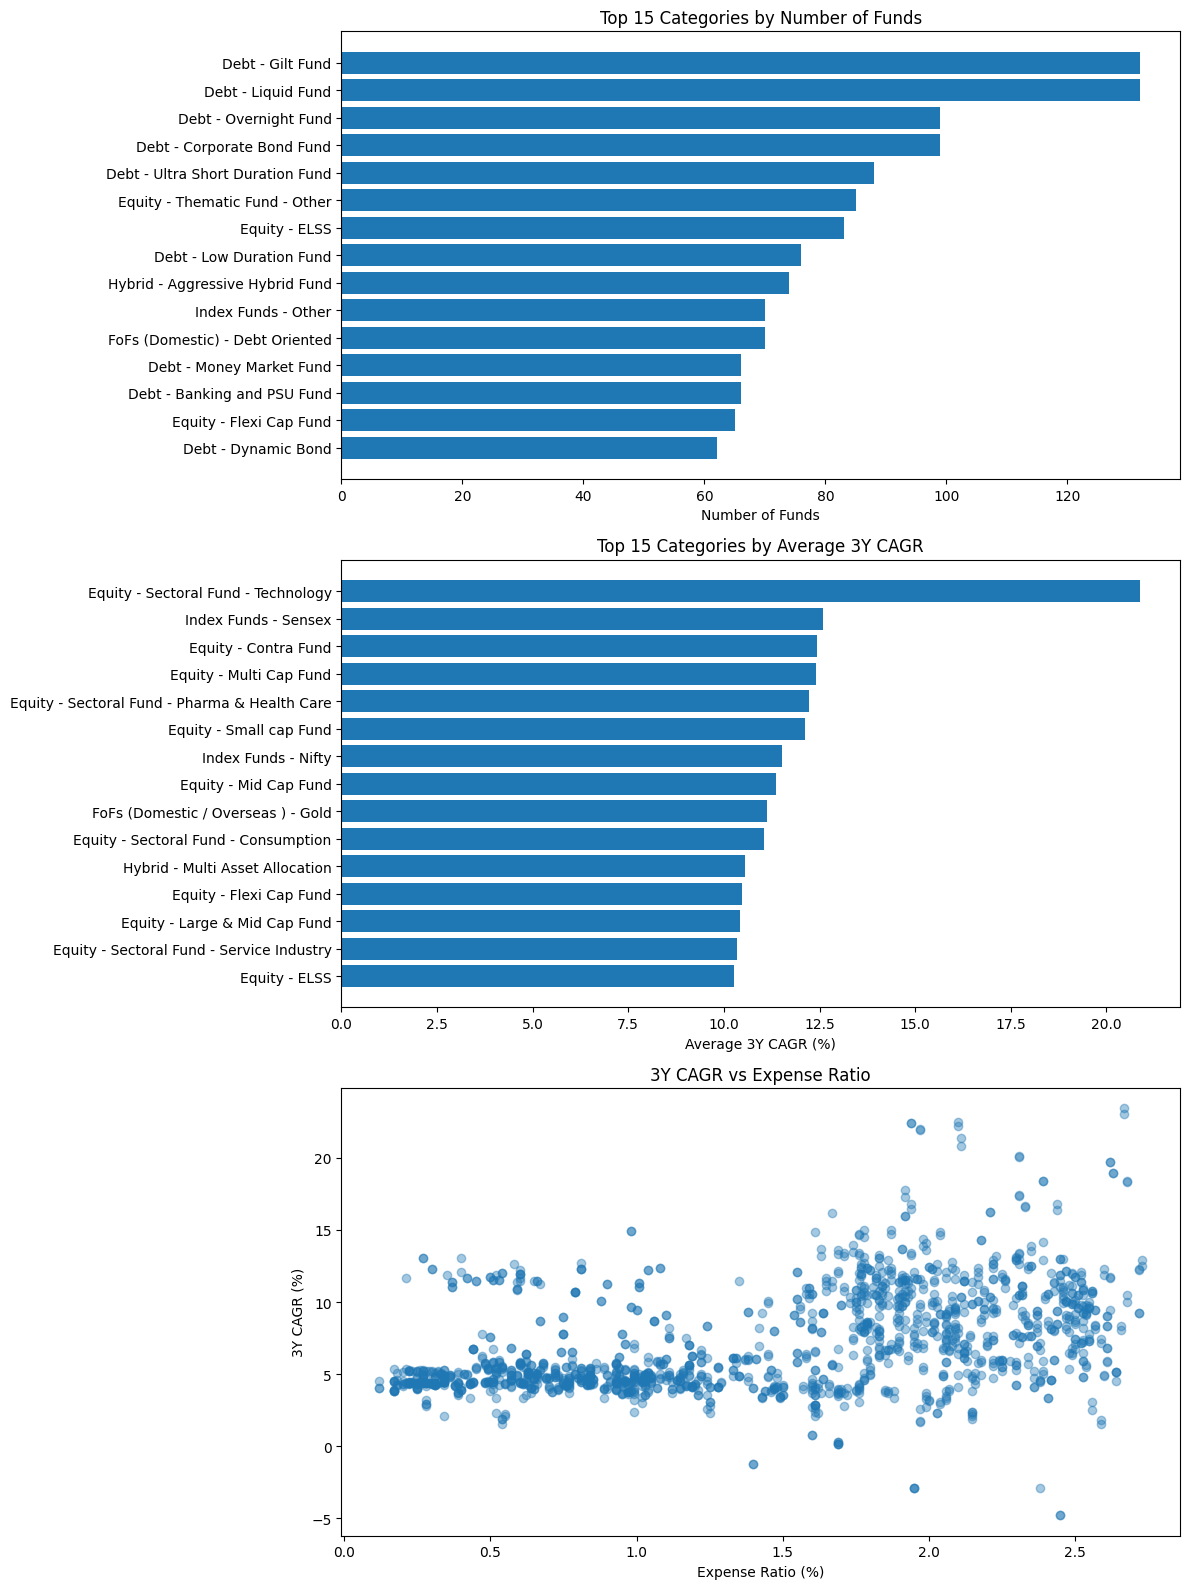

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# 1. Top 15 categories by number of funds
top_counts = df["Category"].value_counts().head(15).sort_values()

axes[0].barh(top_counts.index, top_counts.values)
axes[0].set_title("Top 15 Categories by Number of Funds")
axes[0].set_xlabel("Number of Funds")

# 2. Top 15 categories by average 3Y CAGR
top_3y = (
    category_summary
    .dropna(subset=["Avg_3Y_Return"])
    .nlargest(15, "Avg_3Y_Return")
    .sort_values("Avg_3Y_Return")
)

axes[1].barh(top_3y.index, top_3y["Avg_3Y_Return"])
axes[1].set_title("Top 15 Categories by Average 3Y CAGR")
axes[1].set_xlabel("Average 3Y CAGR (%)")

# 3. 3Y CAGR vs Expense Ratio
plot_data = df[["CAGR% 3 Year", "Exp. Ratio(%)"]].dropna()

axes[2].scatter(
    plot_data["Exp. Ratio(%)"],
    plot_data["CAGR% 3 Year"],
    alpha=0.4
)
axes[2].set_title("3Y CAGR vs Expense Ratio")
axes[2].set_xlabel("Expense Ratio (%)")
axes[2].set_ylabel("3Y CAGR (%)")

plt.tight_layout()
plt.show()

In [32]:
score_cols = [
    "Scheme",
    "Category",
    "CAGR% 6 Months",
    "CAGR% 1 Year",
    "CAGR% 3 Year",
    "Exp. Ratio(%)"
]

score_df = df[score_cols].dropna().copy()

print("Funds available for scoring:", len(score_df))

Funds available for scoring: 1608


,CAGR% 6 Months,CAGR% 1 Year,CAGR% 3 Year,Exp. Ratio(%)
count,1608.000000,1608.000000,1608.000000,1608.000000
mean,4.455690,9.034409,7.164614,1.427917
std,4.036591,6.875299,3.581227,0.738840
min,-24.340000,-11.470000,-4.790000,0.120000
25%,3.370000,3.940000,4.477500,0.760000
50%,4.970000,5.380000,5.840000,1.550000
75%,5.740000,13.920000,9.752500,2.060000
max,22.210000,46.810000,23.430000,2.730000


In [34]:
from sklearn.preprocessing import MinMaxScaler

return_cols = [
    "CAGR% 6 Months",
    "CAGR% 1 Year",
    "CAGR% 3 Year"
]

scaler = MinMaxScaler()

score_df[["6M_Score", "1Y_Score", "3Y_Score"]] = scaler.fit_transform(
    score_df[return_cols]
) * 100

score_df[["6M_Score", "1Y_Score", "3Y_Score"]].head()

,6M_Score,1Y_Score,3Y_Score
0,63.136412,26.012354,35.719348
1,63.136412,26.012354,35.825656
2,63.480129,26.715854,32.742736
3,63.480129,26.835964,35.683912
4,63.243824,26.681537,32.671864


In [ ]:
# Performance Score
score_df["Performance_Score"] = (
    score_df["6M_Score"] * 0.20 +
    score_df["1Y_Score"] * 0.30 +
    score_df["3Y_Score"] * 0.50
)

# Cost Efficiency Score
expense_scaler = MinMaxScaler()

score_df["Cost_Score"] = (
    1 - expense_scaler.fit_transform(
        score_df[["Exp. Ratio(%)"]]
    )
) * 100

# Consistency Score
score_df["Return_Std"] = score_df[
    ["6M_Score", "1Y_Score", "3Y_Score"]
].std(axis=1)

max_possible_std = np.std([0, 0, 100], ddof=1)

score_df["Consistency_Score"] = (
    100 - (score_df["Return_Std"] / max_possible_std * 100)
).clip(0, 100)

# Overall Score
score_df["Overall_Score"] = (
    score_df["Performance_Score"] * 0.50 +
    score_df["Cost_Score"] * 0.25 +
    score_df["Consistency_Score"] * 0.25
)

score_df[
    [
        "Scheme",
        "Performance_Score",
        "Cost_Score",
        "Consistency_Score",
        "Overall_Score"
    ]
].head()

,Scheme,Performance_Score,Cost_Score,Consistency_Score,Overall_Score
0,Kotak Corporate Bond Fund(M-IDCW),38.290663,78.927203,61.493578,54.250527
1,Kotak Corporate Bond Fund(G),38.343817,78.927203,61.525991,54.285207
2,Aditya Birla SL Liquid Fund(DD-IDCW),37.082150,91.570881,60.564631,56.574953
3,Aditya Birla SL Liquid Fund(G),38.588771,91.570881,61.757697,57.626530
4,Aditya Birla SL Liquid Fund(W-IDCW),36.989158,91.570881,60.779856,56.582263
